In [14]:
import ast 
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown

from pathlib import Path
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.notebooks.eda import *
from birdclef_2026_ml.processing.preprocess import *
from birdclef_2026_ml.paths import load_project_paths

paths = load_project_paths()
init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
train = pd.read_parquet(paths.train_processed)
taxonomy = pd.read_csv(paths.taxonomy)
soundscapes = pd.read_parquet(paths.soundscapes_processed)
soundscapes

,filename,start,end,primary_label,primary_label_list,site,datetime,start_sec,end_sec,class_name_list,primary_label_int_list,class_name_int_list
index,,,,,,,,,,,,
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,0.0,5.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,5.0,10.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,10.0,15.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,15.0,20.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,20.0,25.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
...,...,...,...,...,...,...,...,...,...,...,...,...
-144109699107324416,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",22,2022-02-19 20:00:00+00:00,35.0,40.0,[Amphibia],"[60, 63]",[0]
1405175944052740,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,40.0,45.0,[Amphibia],"[57, 60]",[0]
359725041677501694,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,45.0,50.0,[Amphibia],"[57, 60]",[0]


In [32]:
soundscapes["class_name_list"].explode().value_counts()

class_name_list
Amphibia    566
Aves        212
Insecta     168
Mammalia     41
Reptilia     13
Name: count, dtype: int64

In [26]:
dt = soundscapes["datetime"]

soundscapes["hour"] = dt.dt.hour.astype("int8")
soundscapes["dayofyear"] = dt.dt.dayofyear.astype("int8")
soundscapes

,filename,start,end,primary_label,primary_label_list,site,datetime,start_sec,end_sec,class_name_list,primary_label_int_list,class_name_int_list,hour,dayofyear
index,,,,,,,,,,,,,,
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,0.0,5.0,[Amphibia],"[8, 15, 21, 57, 63]",[0],20,109
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,5.0,10.0,[Amphibia],"[8, 15, 21, 57, 63]",[0],20,109
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,10.0,15.0,[Amphibia],"[8, 15, 21, 57, 63]",[0],20,109
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,15.0,20.0,[Amphibia],"[8, 15, 21, 57, 63]",[0],20,109
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,20.0,25.0,[Amphibia],"[8, 15, 21, 57, 63]",[0],20,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-144109699107324416,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",22,2022-02-19 20:00:00+00:00,35.0,40.0,[Amphibia],"[60, 63]",[0],20,50
1405175944052740,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,40.0,45.0,[Amphibia],"[57, 60]",[0],20,50
359725041677501694,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,45.0,50.0,[Amphibia],"[57, 60]",[0],20,50


In [1]:
# Common name composition by site and month (row-normalized)
sl = soundscapes[["site", "datetime", "primary_label_list"]].explode("primary_label_list")
sl = sl.merge(taxonomy, left_on="primary_label_list", right_on="primary_label")
sl["month"] = sl["datetime"].dt.month

for col, y_label in [("site", "Site"), ("month", "Month")]:
    pivot = sl.groupby([col, "common_name"]).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    fig = plt.figure(figsize=(15, 5))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.1)
    plt.xlabel("Common name")
    plt.ylabel(y_label)
    plt.tight_layout()
    fig.savefig(f"plots/data_exploration/ss_primary_label_per_{col}.jpg", bbox_inches="tight", dpi=300)

NameError: name 'soundscapes' is not defined

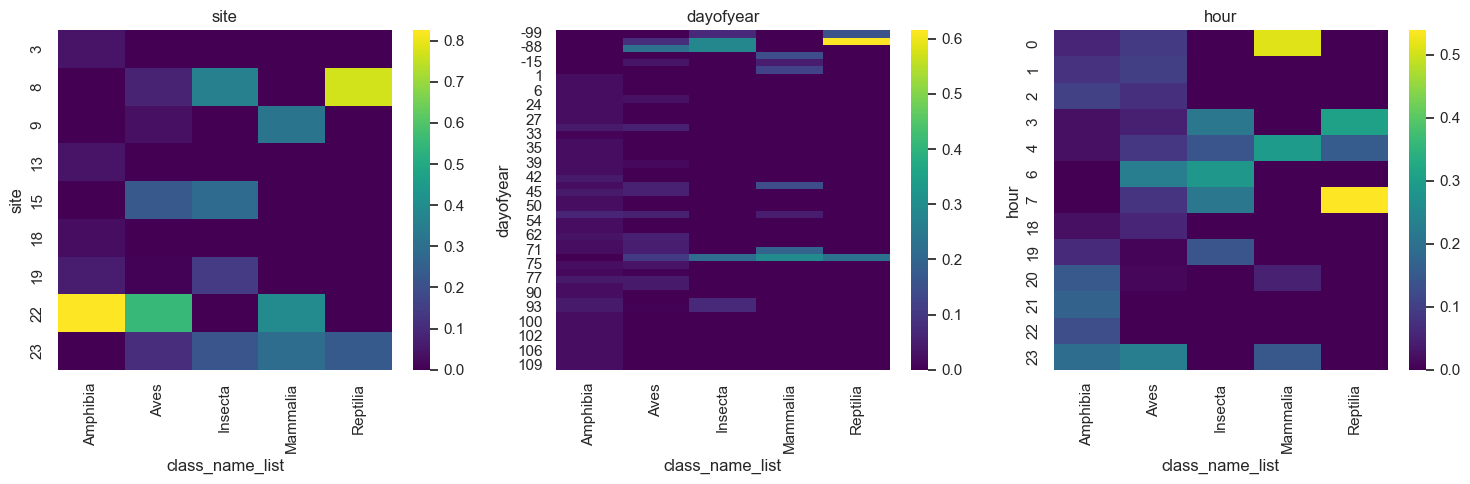

In [27]:
stats = soundscapes.explode("class_name_list").reset_index(drop=True)

fig, axes = plt.subplots(1,3, figsize=(15, 5))

cols = ["site", "dayofyear", "hour"]
for ax, col in zip(axes, cols):
    coocc = pd.crosstab(index=stats[col], columns=stats["class_name_list"], normalize="columns")
    sns.heatmap(coocc, annot=False, cmap="viridis", ax=ax, fmt=".2f")
    ax.set_title(col)
plt.tight_layout()

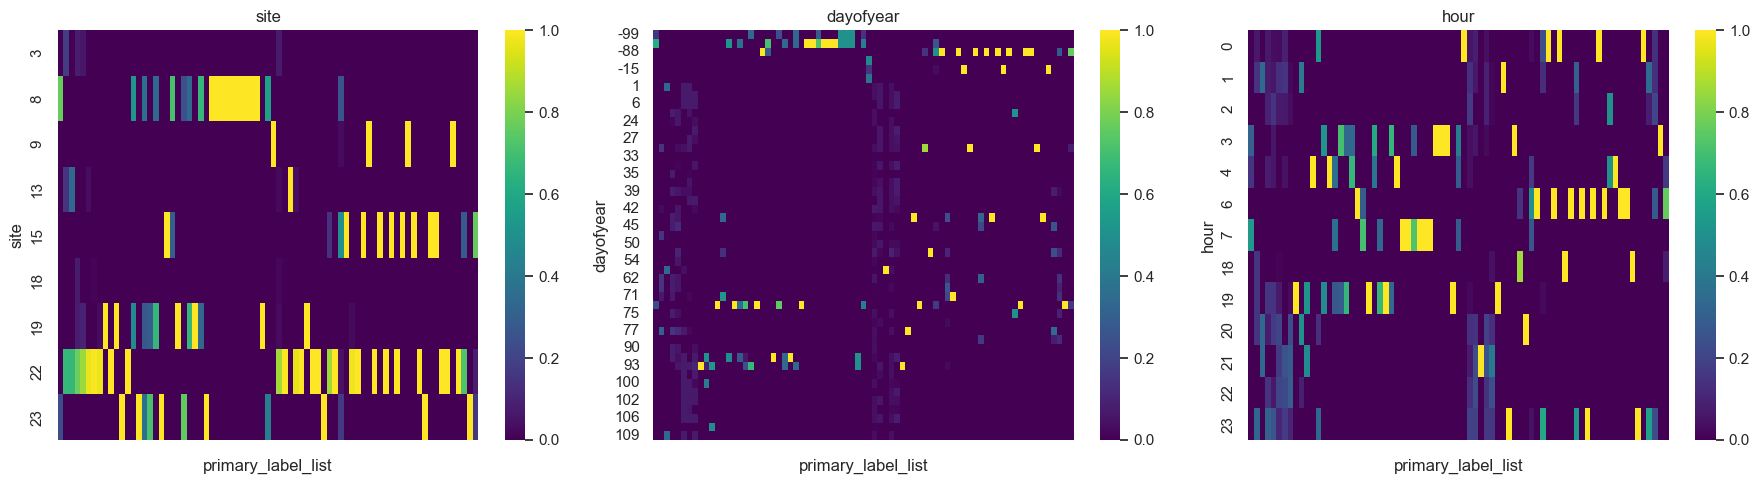

In [28]:
stats = soundscapes.explode("primary_label_list").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cols = ["site", "dayofyear", "hour"]
for ax, col in zip(axes, cols):
    coocc = pd.crosstab(index=stats[col], columns=stats["primary_label_list"], normalize="columns")
    sns.heatmap(coocc, annot=False, cmap="viridis", ax=ax, fmt=".2f")
    ax.set_xticklabels([])
    ax.set_title(col)
plt.tight_layout()

In [ ]:
# Combine primary_label (str) and secondary_labels (list) into a single list for each row
def combine_labels(row):
    return [row["primary_label"]] + row["secondary_labels"]

ss_labels = soundscapes["primary_label_list"].explode()
df = train[["primary_label", "secondary_labels"]].copy()
df["all_labels"] = df.apply(combine_labels, axis=1)

In [59]:
# Build a sorted union of all unique labels from train and soundscapes
all_labels = pd.Index(df["all_labels"].explode().unique()).union(pd.Index(ss_labels)).sort_values()

mlb = MultiLabelBinarizer(classes=np.unique(all_labels))  # multi-hot encoding with consistent order
Y_train = mlb.fit_transform(df["all_labels"])

# Compute co-occurrence matrix for train
C_train = Y_train.T @ Y_train
np.fill_diagonal(C_train, 0)
row_sums = C_train.sum(axis=1, keepdims=True)
C_train = np.divide(C_train, row_sums, where=row_sums!=0)
C_train = np.nan_to_num(C_train, nan=0)

# Compute co-occurrence matrix for soundscapes
Y_soundscapes = mlb.transform(soundscapes["primary_label_list"])
C_soundscapes = Y_soundscapes.T @ Y_soundscapes
np.fill_diagonal(C_soundscapes, 0)
row_sums_sc = C_soundscapes.sum(axis=1, keepdims=True)
C_soundscapes = np.divide(C_soundscapes, row_sums_sc, where=row_sums_sc!=0)
C_soundscapes = np.nan_to_num(C_soundscapes, nan=0)

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_98433/2727474374.py:11: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  C_train = np.divide(C_train, row_sums, where=row_sums!=0)
/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_98433/2727474374.py:19: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  C_soundscapes = np.divide(C_soundscapes, row_sums_sc, where=row_sums_sc!=0)


<Axes: >

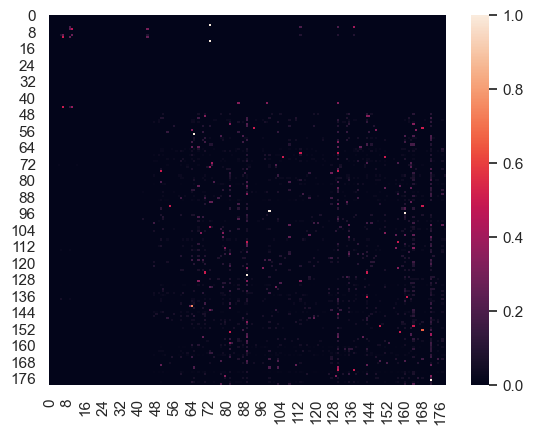

In [60]:
sns.heatmap(C_train)

<Axes: >

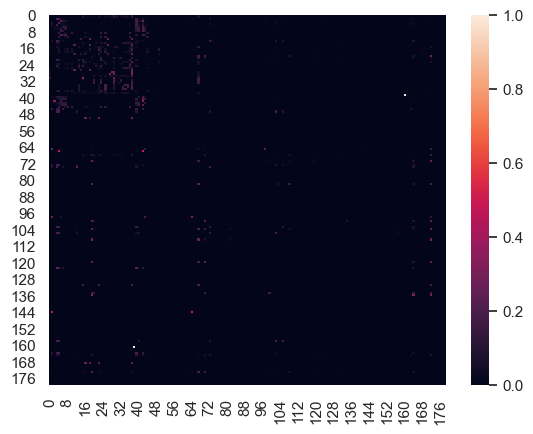

In [61]:
sns.heatmap(C_soundscapes)